In [1]:
import pandas as pd
import sys, os
import torch
print(torch.__version__)

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
print(module_path)
from models.CropTypeClassifier import *
import seaborn as sns
from datasets.constants import *
from explainability_analysis.transformer_analysis import *

2.0.0+cu117
/home/luca/luca_docker/crop-type-classification-explainability


In [20]:
num_heads = 1
tmsp = 1740671725
n_classes=12
classmapping = pd.read_csv('/home/luca/luca_docker/datasets/BavarianCrops/classmapping12.csv')
model_path = f"/home/luca/luca_docker/results/crop-type-classification-explainability/{n_classes}_classes/ltae/right_padding/obs_aq_date/layers=1,heads={num_heads},emb_dim=128/rmse/focal_loss_ratio=100/all_dates/{tmsp}/best_model.pth"
assert os.path.exists(model_path), f'The provided resulting directory does not contain the learned model: {model_path}'

crop_type_classifier_model = init_model_with_hyper_params(
        input_channels=13,
        sequence_length=144,
        num_classes=n_classes,
        pos_enc_opt='obs_aq_date',
        d_model=128,
        num_layers=1,
        num_heads=num_heads,
        use_lightweight=True,
        use_bias=True)

crop_type_classifier_model.load(model_path)
outlinear_weights = crop_type_classifier_model.outlinear.weight.cpu().detach().numpy()
print(outlinear_weights)

Attention_cols = [f"Attention_H{i+1}" for i in range(num_heads)]
heads_weights_df = pd.DataFrame(columns=['Crop Type'] + Attention_cols)
for crop_idx in range(outlinear_weights.shape[0]):
    heads_weights_df.loc[crop_idx] = [classmapping[classmapping['id'] == crop_idx].iloc[0]['classname']] + list(outlinear_weights[crop_idx, :].astype(float))

display(heads_weights_df)

Using original Lightweight Temporal Attention Encoder (LTAE)
Initialized the transformer encoder with the following parameters: obs_aq_date/layers=1,heads=1,emb_dim=128
loading model from /home/luca/luca_docker/results/crop-type-classification-explainability/12_classes/ltae/right_padding/obs_aq_date/layers=1,heads=1,emb_dim=128/rmse/focal_loss_ratio=100/all_dates/1740671725/best_model.pth
[[-0.96664846]
 [-1.1043864 ]
 [ 0.5841011 ]
 [-1.452624  ]
 [-0.04274021]
 [ 0.36372197]
 [ 0.26062757]
 [ 0.5248536 ]
 [ 0.26402465]
 [ 0.08108749]
 [ 0.4586957 ]
 [ 0.12558709]]


,Crop Type,Attention_H1
0,fallow,-0.966648
1,grassland,-1.104386
2,winter wheat,0.584101
3,corn,-1.452624
4,summer wheat,-0.042740
5,winter spelt,0.363722
6,winter rye,0.260628
7,winter barley,0.524854
8,summer barley,0.264025
9,summer oat,0.081087


Using original Lightweight Temporal Attention Encoder (LTAE)
Initialized the transformer encoder with the following parameters: obs_aq_date/layers=1,heads=4,emb_dim=128
loading model from /home/luca/luca_docker/results/crop-type-classification-explainability/12_classes/ltae/right_padding/obs_aq_date/layers=1,heads=4,emb_dim=128/rmse/focal_loss_ratio=100/all_dates/1740852105/best_model.pth


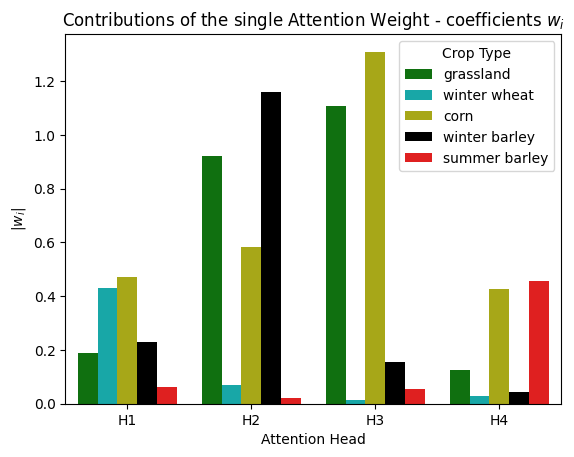

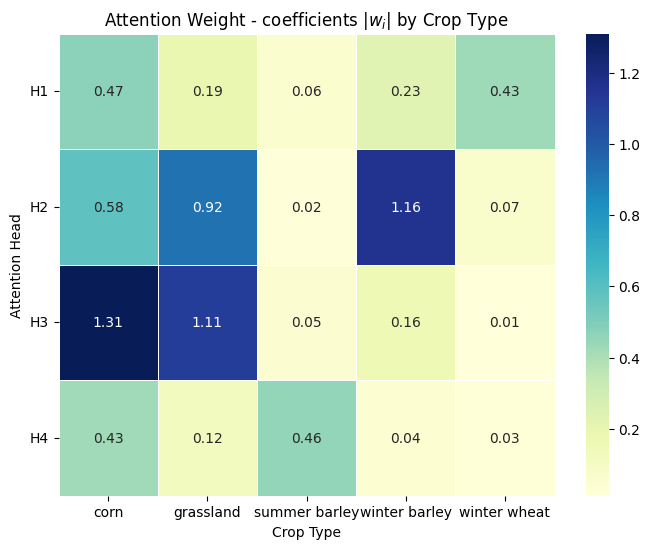

In [5]:
base_model_path = "/home/luca/luca_docker/results/crop-type-classification-explainability"

dataset = 'BavarianCrops'
encoder = 'ltae_original'
num_heads = 4
loss_fn = 'rmse/'
alpha = 1
timestamp = '1740852105'

weights_outlinear_per_weight = get_out_weigths_per_attention(base_model_path, "all_dates", timestamp, num_heads, encoder, loss_fn, alpha, dataset=dataset)

head_labels = {colname:colname.split('_')[1] for colname in weights_outlinear_per_weight.columns.values[1:]}

target_classes = ["grassland","corn", "summer barley", "winter wheat","winter barley"]
class_weights_df = weights_outlinear_per_weight[weights_outlinear_per_weight['Crop type'].isin(target_classes)]
class_weights_df = class_weights_df.rename(columns=head_labels)

class_weights_melted = class_weights_df.melt(id_vars="Crop type", var_name="Attention", value_name="Value")
class_weights_melted['Value'] = class_weights_melted['Value'].abs()

# plt.figure(figsize=(10, 6))
sns.barplot(data=class_weights_melted, x='Attention', y='Value', hue='Crop type', dodge=True, palette=CROP_TYPE_COLOR_MAPPING)
plt.title('Contributions of the single Attention Weight - coefficients $w_i$')
plt.ylabel('$|w_i|$')
plt.xlabel('Attention Head')
plt.legend(title='Crop Type')
plt.show()



# Pivot the DataFrame to have 'Crop type' as columns and 'Attention' as index
pivot_df = class_weights_melted.pivot(index='Attention', columns='Crop type', values='Value')
pivot_df = pivot_df.loc[[colname.split('_')[1] for colname in weights_outlinear_per_weight.columns.values[1:]]]

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_df, cmap='YlGnBu', annot=True, fmt=".2f", linewidths=.5)
plt.title('Attention Weight - coefficients $|w_i|$ by Crop Type')
plt.ylabel('Attention Head')
plt.yticks(rotation=0) 
plt.xlabel('Crop Type')
plt.show()